<a href="https://colab.research.google.com/github/JanhaviSoni7/Sentiment-Analysis-on-Hindi-Twitter-Comments/blob/main/NLP_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Sentiment Analysis on Hindi Twitter Comments

In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Section 1: Load the Dataset

In [ ]:

df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRV4Z9gaonjgGEYZRBaKtwmKMv0sLbgG58iVlXjlga0hMPjiqMuI0Wb40YWesIZ1llhsn0IYdcShGWm/pub?output=csv')
df.head()

,Review,Sentiment
0,गुमनाम है वतन पर मिटने वाले लोग आतन्कवादियों स...,negative
1,ज़ंजीर बदली जा रही थी मैं समझा था रिहाई हो गयी है,negative
2,यूपी में बड़े स्तर पर दंगे करवा सकती है बीजेपी...,negative
3,अंग्रेजी नहीं आती है इसलिए हिन्दी ट्विट ज्यादा...,negative
4,कश्मीर में हो रहा है जल जिहाद ।,negative


Section 2: Perform Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9076 entries, 0 to 9075
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     9076 non-null   object
 1   Sentiment  9076 non-null   object
dtypes: object(2)
memory usage: 141.9+ KB
None
                                                   Review Sentiment
count                                                9076      9076
unique                                               7831         3
top     ससुर ने किया बलात्कार ISLAMIC LAW-NOW WIFE IS ...  positive
freq                                                    8      3254


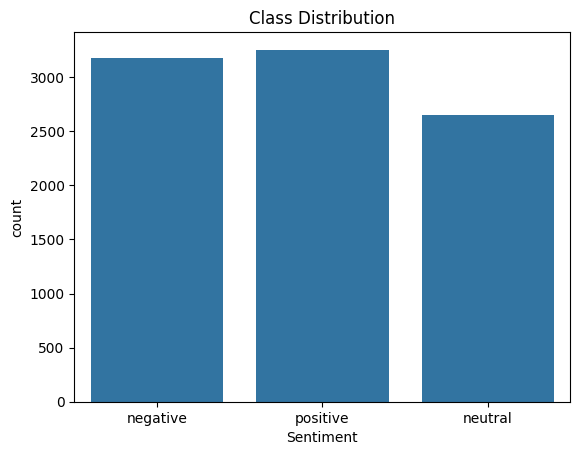

Review       0
Sentiment    0
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display dataset info and summary statistics
print(df.info())
print(df.describe())

# Visualize the class distribution (if it's a classification task)
sns.countplot(x='Sentiment', data=df)
plt.title("Class Distribution")
plt.show()

# Check for missing values
print(df.isnull().sum())

Section 3: Perform Text Processing on Dataset

In [ ]:

import re
import string
# Updated rule-based Hindi stopwords, including Twitter-specific terms
stop_words = set([
    "और", "के", "का", "है", "इस", "को", "में", "की", "से", "कि", "पर",
    "एक", "हैं", "यह", "भी", "था", "तो", "वे", "अब", "तक",
    "हम", "आप", "तुम", "वह", "उस", "उन", "जो", "जब", "जहां",
    "कोई", "कुछ", "सब", "यदि", "कभी", "सभी", "इन", "उनका", "इसका", "उन्हें",
    "लिए", "जैसे", "थे", "कर", "करने", "करता", "करती", "करते", "होता", "होती",
    "था", "थी", "रहा", "रही", "रहे",
    "बाद", "अब", "ही", "गया", "गई", "गए", "थे", "थीं", "था", "थी",

    # Twitter-specific stopwords
    "rt", "@user", "http", "https", "www", "com", "co", "link", "url",  # Remove mentions & URLs
    "😂", "🤣", "😅", "😍", "😊", "🙄", "😡", "😢", "😎",  # Common emojis in tweets
    "हूँ", "अभी", "सिर्फ", "वहाँ", "हमारे", "उनके", "तभी", "इन्हें", "उन्हें"
])

# Define function for tweet text preprocessing
def clean_text(text):
    text = str(text)  # Ensure text is string
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Remove @mentions
    text = re.sub(r'http\S+|www\S+|co\S+', '', text)  # Remove URLs
    text = re.sub(r'#\S+', '', text)  # Remove hashtags
    text = re.sub(r'[^ऀ-ॿ\s]', '', text)  # Keep only Hindi characters
    text = text.lower().strip()  # Convert to lowercase & remove extra spaces
    words = text.split()  # Tokenization
    cleaned_words = [word for word in words if word not in stop_words]  # Remove stopwords
    return ' '.join(cleaned_words)

# Apply preprocessing
df['cleaned_text'] = df['Review'].apply(clean_text)
# Save cleaned dataset
df.to_csv("cleanedHindiDataset.csv", index=False)

print("Tweet preprocessing completed. Cleaned dataset saved as 'cleanedHindiDataset.csv'.")

Tweet preprocessing completed. Cleaned dataset saved as 'cleanedHindiDataset.csv'.


In [ ]:
df = pd.read_csv('/content/cleanedHindiDataset.csv')
df.head()

,Review,Sentiment,cleaned_text
0,गुमनाम है वतन पर मिटने वाले लोग आतन्कवादियों स...,negative,गुमनाम वतन मिटने वाले लोग आतन्कवादियों मिलकर म...
1,ज़ंजीर बदली जा रही थी मैं समझा था रिहाई हो गयी है,negative,ज़ंजीर बदली जा मैं समझा रिहाई हो गयी
2,यूपी में बड़े स्तर पर दंगे करवा सकती है बीजेपी...,negative,यूपी बड़े स्तर दंगे करवा सकती बीजेपी मुलायम सि...
3,अंग्रेजी नहीं आती है इसलिए हिन्दी ट्विट ज्यादा...,negative,अंग्रेजी नहीं आती इसलिए हिन्दी ट्विट ज्यादा । ...
4,कश्मीर में हो रहा है जल जिहाद ।,negative,कश्मीर हो जल जिहाद ।


Section 4: Generate NLP-Based Features

In [ ]:
def generate_nlp_features(df):
    # Character count
    # Applying len to a float (NaN) will raise TypeError.
    # Using a lambda function to handle NaN values by returning 0.
    df['char_count'] = df['cleaned_text'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    # Word count
    df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    # Average word length
    df['avg_word_length'] = df['cleaned_text'].apply(lambda x: np.mean([len(word) for word in str(x).split()]) if pd.notna(x) and len(str(x).split()) > 0 else 0)
    # Stopword count
    df['stopword_count'] = df['cleaned_text'].apply(lambda x: len([word for word in str(x).split() if word in stop_words]) if pd.notna(x) else 0)
    # Hashtag count (for datasets like tweets)
    df['htag_count'] = df['cleaned_text'].apply(lambda x: str(x).count('#') if pd.notna(x) else 0)

    return df

# Generate NLP features
df = generate_nlp_features(df)
df[['char_count', 'word_count', 'avg_word_length', 'stopword_count', 'htag_count']].head()


,char_count,word_count,avg_word_length,stopword_count,htag_count
0,57,10,4.800,0,0
1,36,8,3.625,0,0
2,53,10,4.400,0,0
3,74,15,4.000,0,0
4,20,5,3.200,0,0


Section 5: Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Replace NaN values in 'cleaned_text' with empty strings
df['cleaned_text'] = df['cleaned_text'].fillna('')
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['cleaned_text'])

# TFIDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [ ]:
df.head()

,Review,Sentiment,cleaned_text,char_count,word_count,avg_word_length,stopword_count,htag_count
0,गुमनाम है वतन पर मिटने वाले लोग आतन्कवादियों स...,negative,गुमनाम वतन मिटने वाले लोग आतन्कवादियों मिलकर म...,57,10,4.800,0,0
1,ज़ंजीर बदली जा रही थी मैं समझा था रिहाई हो गयी है,negative,ज़ंजीर बदली जा मैं समझा रिहाई हो गयी,36,8,3.625,0,0
2,यूपी में बड़े स्तर पर दंगे करवा सकती है बीजेपी...,negative,यूपी बड़े स्तर दंगे करवा सकती बीजेपी मुलायम सि...,53,10,4.400,0,0
3,अंग्रेजी नहीं आती है इसलिए हिन्दी ट्विट ज्यादा...,negative,अंग्रेजी नहीं आती इसलिए हिन्दी ट्विट ज्यादा । ...,74,15,4.000,0,0
4,कश्मीर में हो रहा है जल जिहाद ।,negative,कश्मीर हो जल जिहाद ।,20,5,3.200,0,0


Section 6: Train All Supervised Models on NLP-Based Features

In [ ]:
# Student Code: Train Models on NLP Features (char_count, word_count, etc.)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X = df[['char_count', 'word_count', 'avg_word_length', 'stopword_count', 'htag_count']]
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model (Random Forest as an example)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

Accuracy: 0.3832599118942731


Sections 7-9: Train Models on Features extracted by vectorizers/word embeddings

In [ ]:
# Train models on Bag of Words (BoW), TFIDF
# Example for Bag of Words
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'BoW Accuracy: {accuracy_score(y_test, y_pred)}')

# Example for TFIDF
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'TFIDF Accuracy: {accuracy_score(y_test, y_pred)}')

BoW Accuracy: 0.6602422907488987
TFIDF Accuracy: 0.6674008810572687


Section 10: Train Models on All Combined Features with the embeddings of your project

In [ ]:
# Student Code: Train Models on Combined Features (NLP + TFIDF)
from scipy.sparse import hstack

# Combine NLP features and TFIDF features
X_combined = hstack([X, X_tfidf])

# Train model and evaluate
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'Combined Features Accuracy: {accuracy_score(y_test, y_pred)}')

Combined Features Accuracy: 0.6613436123348018


Section 11: Save the Model and Make Predictions on Real-World Input

In [ ]:
# Student Code: Save the model and make predictions on new data
import joblib
from scipy.sparse import hstack # Import hstack for combining features

# ... (rest of your code) ...

# Example: Make predictions on real-world input (e.g., a new text)
new_text = ["ट्रैफिक जाम ने पूरा दिन खराब कर दिया! 😤"]
new_text_cleaned = [clean_text(text) for text in new_text]

# Generate NLP features for the new text
new_text_df = pd.DataFrame({'cleaned_text': new_text_cleaned})  # Create a DataFrame for the new text
new_text_df = generate_nlp_features(new_text_df)  # Apply the NLP feature generation function
new_text_nlp_features = new_text_df[['char_count', 'word_count', 'avg_word_length', 'stopword_count', 'htag_count']]

# Generate TFIDF features for the new text
new_text_tfidf_features = tfidf_vectorizer.transform(new_text_cleaned)

# Combine NLP and TFIDF features for the new text
# Instead of using X, which has only 5 NLP features, use new_text_nlp_features
# which also has 5 features, but for the new text data.
new_text_features = hstack([new_text_nlp_features, new_text_tfidf_features])

# Re-train the model on the combined features to ensure it's expecting the correct number of features (39)
# Split the original combined data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Re-train the model on the combined features
model.fit(X_train, y_train)

# Predict using the trained model
prediction = model.predict(new_text_features)
print(f'Prediction for new text: {prediction}')

Prediction for new text: ['negative']


Prediction

In [ ]:
# # Assuming the model and necessary objects (tfidf_vectorizer, etc.) are already loaded as in the provided code.

# new_text = input("Enter Hindi text: ")
# new_text_cleaned = [clean_text(new_text)]

# # Generate NLP features for the new text
# new_text_df = pd.DataFrame({'cleaned_text': new_text_cleaned})
# new_text_df = generate_nlp_features(new_text_df)
# new_text_nlp_features = new_text_df[['char_count', 'word_count', 'avg_word_length', 'stopword_count', 'htag_count']]

# # Generate TFIDF features for the new text
# new_text_tfidf_features = tfidf_vectorizer.transform(new_text_cleaned)

# # Combine NLP and TFIDF features for the new text
# new_text_features = hstack([new_text_nlp_features, new_text_tfidf_features])

# # Predict using the trained model
# prediction = model.predict(new_text_features)
# print(f'Prediction for new text: {prediction}')


Train using DL Model

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm
import transformers
import pandas as pd
from transformers import AutoModel
from transformers import BertForSequenceClassification

In [ ]:
class HindiSentimentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length, label_map):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.label_map = label_map

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data.iloc[idx]['Review']
        label_str = self.data.iloc[idx]['Sentiment']
        label = self.label_map[label_str]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
label_map = {'negative': 0,'positive':1 ,'neutral':2}
# Define the model
model = BertForSequenceClassification.from_pretrained("ai4bharat/indic-bert", num_labels=len(label_map))
tokenizer = transformers.AutoTokenizer.from_pretrained('ai4bharat/indic-bert', keep_accents=True)
tokenizer

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

You are using a model of type albert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

AlbertTokenizerFast(name_or_path='ai4bharat/indic-bert', vocab_size=200000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '<unk>', 'sep_token': '[SEP]', 'pad_token': '<pad>', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)

In [ ]:
# Define training parameters
batch_size = 32
max_length = 256
epochs = 5
learning_rate = 3e-5
# Create dataloaders for training and validation
train_dataset = HindiSentimentDataset(train_df, tokenizer, max_length, label_map)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = HindiSentimentDataset(val_df, tokenizer, max_length, label_map)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
train_dataset.__len__()

7260

In [ ]:
# Define optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(200000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch in tqdm(train_loader, desc="Epoch " + str(epoch + 1) + "/" + str(epochs)):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Evaluate on validation set
    model.eval()
    val_accuracy = 0
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            val_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            val_accuracy += (predicted == labels).sum().item()

    print('Epoch:', epoch + 1, 'Train Loss:', running_loss / len(train_loader), 'Val Loss:', val_loss / len(val_loader), 'Val Accuracy:', val_accuracy / len(val_dataset))


Epoch 1/5: 100%|██████████| 227/227 [04:48<00:00,  1.27s/it]


Epoch: 1 Train Loss: 0.7932865477868639 Val Loss: 0.731550513652333 Val Accuracy: 0.5600220264317181


Epoch 2/5: 100%|██████████| 227/227 [04:54<00:00,  1.30s/it]


Epoch: 2 Train Loss: 0.5824564241102613 Val Loss: 0.4712357730196233 Val Accuracy: 0.8061674008810573


Epoch 3/5: 100%|██████████| 227/227 [04:53<00:00,  1.29s/it]


Epoch: 3 Train Loss: 0.3497003960189315 Val Loss: 0.43568321722641323 Val Accuracy: 0.8397577092511013


Epoch 4/5: 100%|██████████| 227/227 [04:53<00:00,  1.29s/it]


Epoch: 4 Train Loss: 0.17295944935227806 Val Loss: 0.4704203451411766 Val Accuracy: 0.8331497797356828


Epoch 5/5: 100%|██████████| 227/227 [04:53<00:00,  1.29s/it]


Epoch: 5 Train Loss: 0.10193096912806517 Val Loss: 0.7120143909726226 Val Accuracy: 0.7979074889867841


In [ ]:
torch.save(model.state_dict(), 'indic_bert_sentiment_model.pth')
# Evaluate the model on the validation set
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy
# Load the saved model
model.load_state_dict(torch.load('indic_bert_sentiment_model.pth'))
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(200000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
# Evaluate the model on the validation set
val_accuracy = evaluate_model(model, val_loader, device)
print('Validation Accuracy:', val_accuracy)

train_accuracy = evaluate_model(model, train_loader, device)
print('Training Accuracy:', train_accuracy)

Validation Accuracy: 0.7979074889867841
Training Accuracy: 0.9615702479338843


In [ ]:
# Make predictions on new data
def predict_sentiment(model, tokenizer, text, max_length, device):
    model.eval()
    inputs = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predicted_label = torch.argmax(logits, dim=1).item()

    sentiment = [key for key, value in label_map.items() if value == predicted_label][0]
    return sentiment

In [ ]:
# Example usage
text = "मुझे लगता है कि इस मुद्दे के बारे में यह जानकारी भी महत्वपूर्ण है।"
predicted_sentiment = predict_sentiment(model, tokenizer, text, max_length, device)
print('Predicted Sentiment:', predicted_sentiment)

Predicted Sentiment: positive


In [ ]:
# Get user input
user_input = input("Enter text: ")

# Predict sentiment
predicted_sentiment = predict_sentiment(model, tokenizer, user_input, max_length, device)
print('Predicted Sentiment:', predicted_sentiment)


Enter text: मुझे यह बिल्कुल पसंद नहीं आया।
Predicted Sentiment: negative


Analysis